In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive has been mounted successfully.")

Mounted at /content/drive
Google Drive has been mounted successfully.


In [ ]:
import os
import glob
import shutil

# 🚨 ZIP_PATH set to the root of MyDrive since files are there directly
ZIP_PATH = '/content/drive/MyDrive/'

# Define the destination where the images will be extracted (a new folder on your Drive)
EXTRACT_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'

# Create the extraction directory
os.makedirs(EXTRACT_DIR, exist_ok=True)
print(f"Extraction directory created: {EXTRACT_DIR}")

# List of all zip files to extract
zip_files = [
    'Evening_Fire_Incident_aug_img.zip',
    'Evening_Forest_Condition_aug_img.zip',
    'Pre-_Evening_Fire_Incident_aug_img.zip',
    'Pre-_Evening_Forest_Condition_aug_img.zip'
]

# Unzip all files using Colab's fast internal connection
for zip_file in zip_files:
    full_zip_path = os.path.join(ZIP_PATH, zip_file)
    if os.path.exists(full_zip_path):
        print(f"Extracting {zip_file}...")
        # Unzip command: -q (quiet mode), -d (destination directory)
        !unzip -q "{full_zip_path}" -d "{EXTRACT_DIR}"
        print(f"Finished extracting {zip_file}.")
    else:
        print(f"Error: {zip_file} not found at {full_zip_path}. Please ensure the names are exact.")

# Verify extraction
print("\nVerifying extraction...")
# Check if the four expected class folders exist in the destination
expected_folders = ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img',
                    'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']
found_count = sum(1 for folder in expected_folders if os.path.isdir(os.path.join(EXTRACT_DIR, folder)))
print(f"Found {found_count} out of 4 expected class folders. Proceed when this finishes.")

Extraction directory created: /content/drive/MyDrive/MHCNNFD_Data/
Extracting Evening_Fire_Incident_aug_img.zip...
Finished extracting Evening_Fire_Incident_aug_img.zip.
Extracting Evening_Forest_Condition_aug_img.zip...
Finished extracting Evening_Forest_Condition_aug_img.zip.
Extracting Pre-_Evening_Fire_Incident_aug_img.zip...
Finished extracting Pre-_Evening_Fire_Incident_aug_img.zip.
Extracting Pre-_Evening_Forest_Condition_aug_img.zip...
Finished extracting Pre-_Evening_Forest_Condition_aug_img.zip.

Verifying extraction...
Found 4 out of 4 expected class folders. Proceed when this finishes.


In [ ]:
# Import all required libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import glob
import os
from sklearn.metrics import classification_report, confusion_matrix # Added for final metrics

In [ ]:
# --- STEP 4a: Create a DataFrame of all image paths and labels ---
# BASE_DIR should match the EXTRACT_DIR from the previous cell
BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'

all_image_paths = []
all_labels = []

# The actual folder names inside the extracted zip are used as class names for glob
class_names_long = ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img',
                    'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']
# Cleaned-up labels for the final model
class_names_short = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                     'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

for long_name, short_name in zip(class_names_long, class_names_short):
    class_dir = os.path.join(BASE_DIR, long_name)

    # Use glob to find all images
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        paths = glob.glob(os.path.join(class_dir, ext))
        all_image_paths.extend(paths)
        all_labels.extend([short_name] * len(paths))

df = pd.DataFrame({'path': all_image_paths, 'label': all_labels})

# Check that the total count is close to 15,560
if len(df) < 15000:
    print(f"Warning: Only {len(df)} images found. Expected ~15,560. Check extraction path or file extensions.")
else:
    print(f"Total images found and framed: {len(df)}")


# --- STEP 4b: Stratified Split (80:10:10) ---

# 1. Split into (Train) and (Temp: Validation + Test)
df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    random_state=42, # Fixed random state for replicability [cite: 222]
    stratify=df['label'] # Ensures class balance [cite: 222]
)

# 2. Split the temporary set into (Validation) and (Test) (50/50 of the Temp set = 10% each)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=42,
    stratify=df_temp['label']
)

print(f"\nTraining set size (80%): {len(df_train)}")
print(f"Validation set size (10%): {len(df_val)}")
print(f"Test set size (10%): {len(df_test)}")

Total images found and framed: 15560

Training set size (80%): 12448
Validation set size (10%): 1556
Test set size (10%): 1556


In [ ]:
def build_mhcnnfd_model(input_shape=(256, 256, 3), num_classes=4):
    """
    Builds the MHCNNFD model architecture
    """
    inputs = tf.keras.Input(shape=input_shape)

    # --- Convolutional Blocks (5 layers, 3x3 kernel) ---

    # Block 1: 32 filters, Max-Pooling 2x2
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='valid', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 2: 48 filters, Max-Pooling 2x2
    x = tf.keras.layers.Conv2D(48, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 3: 56 filters (Max-Pooling assumed for spatial reduction)
    x = tf.keras.layers.Conv2D(56, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 4: 64 filters
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='valid', activation='relu')(x)

    # Dropout (Rate 0.1) after the fourth convolutional layer [cite: 192]
    x = tf.keras.layers.Dropout(0.1)(x)

    # Block 5: 32 filters
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='valid', activation='relu')(x)

    # --- Classification Head ---

    # Global Average Pooling (GAP) [cite: 193]
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Fully Connected Layers (using SELU activation) [cite: 194]
    x = tf.keras.layers.Dense(64, activation='selu')(x)
    x = tf.keras.layers.Dense(56, activation='selu')(x)
    x = tf.keras.layers.Dense(32, activation='selu')(x)

    # Output Layer: 4 classes, SoftMax activation [cite: 195]
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='MHCNNFD')

    return model

# Initialize the model
# The number of classes is 4 (Pre-evening Forest, Evening Forest, Pre-evening Fire, Evening Fire)
NUM_CLASSES = len(df['label'].unique())
mhcnnfd_model = build_mhcnnfd_model(num_classes=NUM_CLASSES)
mhcnnfd_model.summary()

Model: "MHCNNFD"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 48)   │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 56)     │        24,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        32,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 56)             │         3,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,508 (380.89 KB)

 Trainable params: 97,508 (380.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Define Image Data Generators ---
IMAGE_SIZE = (256, 256) # Input size as specified in the paper
BATCH_SIZE = 32         # Batch size as specified in the paper
TARGET_CLASSES = df['label'].unique().tolist()

# BASE_DIR should match the EXTRACT_DIR from the previous cell (used for file path lookup)
BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'

# Data Generator with simple rescaling (0-1)
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Flow from DataFrame to load and preprocess images
train_generator = datagen.flow_from_dataframe(
    dataframe=df_train,
    directory=BASE_DIR,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES,
    shuffle=True
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=df_val,
    directory=BASE_DIR,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES,
    shuffle=False
)

# Test generator (no shuffling for final evaluation)
test_generator = datagen.flow_from_dataframe(
    dataframe=df_test,
    directory=BASE_DIR,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES,
    shuffle=False
)

# --- Define the Learning Rate Scheduler Callback ---

def lr_scheduler(epoch):
    """Progressive decay in the learning rate (lr) across epochs as per the paper[cite: 196, 197]."""
    if epoch < 15:
        return 1e-3 # Epochs 1-14: 1e-3
    elif epoch < 31:
        return 1e-4 # Epochs 15-30: 1e-4
    else:
        return 1e-5 # Epochs 31-40: 1e-5

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# --- Compile the Model ---
# Use the Adam optimizer and Categorical Cross-Entropy loss [cite: 196, 198]
mhcnnfd_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Initial LR set to 1e-3
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compilation and LR scheduler defined. Ready for training.")

Found 12448 validated image filenames belonging to 4 classes.
Found 1556 validated image filenames belonging to 4 classes.
Found 1556 validated image filenames belonging to 4 classes.
Model compilation and LR scheduler defined. Ready for training.


In [ ]:
print("Starting MHCNNFD Model Training (40 Epochs)...")

EPOCHS = 40
STEPS_PER_EPOCH = 104 # As specified in the paper

history = mhcnnfd_model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[lr_callback]
)

print("\nModel training complete. Moving to evaluation.")

Starting MHCNNFD Model Training (40 Epochs)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 90s 761ms/step - accuracy: 0.6103 - loss: 0.8326 - val_accuracy: 0.9467 - val_loss: 0.2278 - learning_rate: 0.0010
Epoch 2/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 67s 653ms/step - accuracy: 0.9137 - loss: 0.2536 - val_accuracy: 0.9672 - val_loss: 0.1422 - learning_rate: 0.0010
Epoch 3/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 66s 641ms/step - accuracy: 0.9612 - loss: 0.1353 - val_accuracy: 0.9698 - val_loss: 0.1080 - learning_rate: 0.0010
Epoch 4/40
 77/104 ━━━━━━━━━━━━━━━━━━━━ 11s 433ms/step - accuracy: 0.9713 - loss: 0.1051

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


104/104 ━━━━━━━━━━━━━━━━━━━━ 52s 507ms/step - accuracy: 0.9699 - loss: 0.1090 - val_accuracy: 0.9730 - val_loss: 0.0823 - learning_rate: 0.0010
Epoch 5/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 69s 660ms/step - accuracy: 0.9764 - loss: 0.0843 - val_accuracy: 0.9332 - val_loss: 0.1793 - learning_rate: 0.0010
Epoch 6/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 67s 648ms/step - accuracy: 0.9631 - loss: 0.1133 - val_accuracy: 0.9717 - val_loss: 0.0933 - learning_rate: 0.0010
Epoch 7/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 65s 632ms/step - accuracy: 0.9600 - loss: 0.1283 - val_accuracy: 0.9679 - val_loss: 0.1370 - learning_rate: 0.0010
Epoch 8/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 52s 509ms/step - accuracy: 0.9756 - loss: 0.0742 - val_accuracy: 0.9653 - val_loss: 0.1038 - learning_rate: 0.0010
Epoch 9/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 67s 643ms/step - accuracy: 0.9835 - loss: 0.0508 - val_accuracy: 0.9820 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 10/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 66s 640ms/step - accuracy: 0.9781 - loss

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- 1. Evaluate on the Test Set (10%) ---
print("Evaluating model on the Test Set (1556 images) using the FINAL saved weights...")

# resetting the generator before evaluation
test_generator.reset()
# We use the full length of the test set for the steps
test_loss, test_accuracy = mhcnnfd_model.evaluate(test_generator, steps=len(df_test)//BATCH_SIZE, verbose=1)

print(f"\n--- REPLICATION TEST RESULTS ---")
print(f"Test Accuracy: {test_accuracy*100:.2f}% (Paper reported peak: 99.81%)")
print(f"Test Loss: {test_loss:.4f} (Paper reported: 0.0052)")

# --- 2. Generate Classification Report and Confusion Matrix ---

# Get predictions
test_generator.reset()
pred_probs = mhcnnfd_model.predict(test_generator, steps=len(df_test)//BATCH_SIZE, verbose=1)

# Convert probabilities to class labels (index)
pred_labels = np.argmax(pred_probs, axis=1)

# Get true labels (index)
true_labels_index = test_generator.classes[:len(pred_probs)]
target_names = list(test_generator.class_indices.keys())

# Print the final report
print("\n--- Classification Report (P, R, F1 for all classes) ---")
print(classification_report(true_labels_index, pred_labels, target_names=target_names))

# Print the Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(true_labels_index, pred_labels)
print(cm)

Evaluating model on the Test Set (1556 images) using the FINAL saved weights...
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 390ms/step - accuracy: 0.9963 - loss: 0.0137

--- REPLICATION TEST RESULTS ---
Test Accuracy: 99.67% (Paper reported peak: 99.81%)
Test Loss: 0.0133 (Paper reported: 0.0052)
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 412ms/step

--- Classification Report (P, R, F1 for all classes) ---
                               precision    recall  f1-score   support

        Evening_Fire_Incident       1.00      1.00      1.00       385
     Evening_Forest_Condition       0.99      1.00      0.99       386
   Pre-_Evening_Fire_Incident       1.00      0.99      0.99       381
Pre-_Evening_Forest_Condition       1.00      1.00      1.00       384

                     accuracy                           1.00      1536
                    macro avg       1.00      1.00      1.00      1536
                 weighted avg       1.00      1.00      1.00      1536


--- Confusion Matrix ---
[[385   0   0   0]

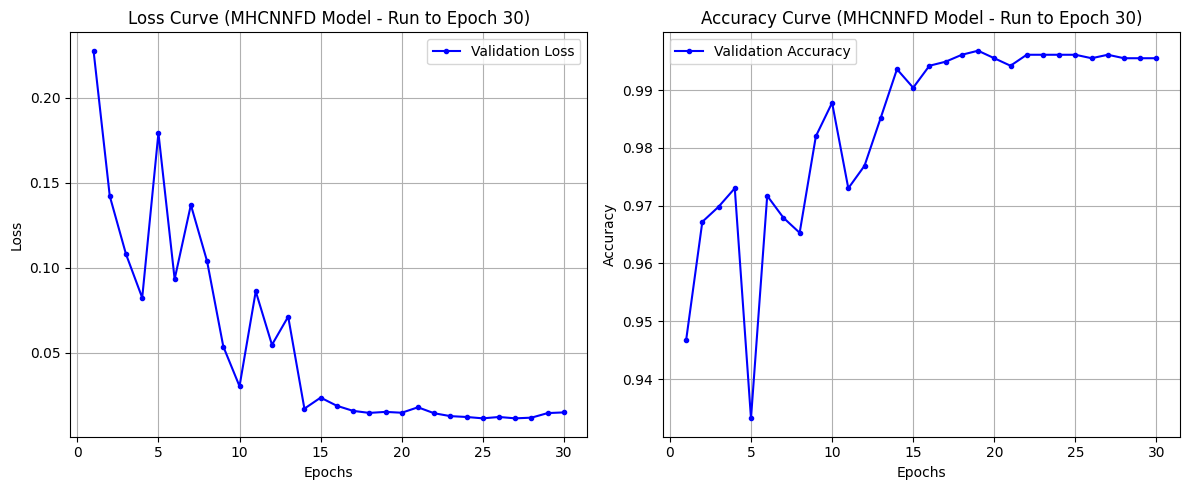

In [ ]:
import matplotlib.pyplot as plt

# Validation Accuracy Log (Up to Epoch 30)
val_accuracy_log = [
    0.9467, 0.9672, 0.9698, 0.9730, 0.9332, 0.9717, 0.9679, 0.9653, 0.9820, 0.9878,
    0.9730, 0.9769, 0.9852, 0.9936, 0.9904, 0.9942, 0.9949, 0.9961, 0.9968, 0.9955,
    0.9942, 0.9961, 0.9961, 0.9961, 0.9961, 0.9955, 0.9961, 0.9955, 0.9955, 0.9955
]

# Validation Loss Log (Up to Epoch 30)
val_loss_log = [
    0.2278, 0.1422, 0.1080, 0.0823, 0.1793, 0.0933, 0.1370, 0.1038, 0.0536, 0.0302,
    0.0861, 0.0546, 0.0712, 0.0170, 0.0235, 0.0187, 0.0157, 0.0145, 0.0151, 0.0146,
    0.0178, 0.0143, 0.0126, 0.0121, 0.0113, 0.0121, 0.0113, 0.0117, 0.0144, 0.0148
]

# --- 2. Plotting the Reconstructed Data ---

# --- Plot Training & Validation Loss ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# X-axis runs from 1 up to the number of epochs logged
plt.plot(range(1, len(val_loss_log) + 1), val_loss_log, label='Validation Loss', color='blue', marker='o', markersize=3)
plt.title('Loss Curve (MHCNNFD Model - Run to Epoch 30)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Plot Training & Validation Accuracy ---
plt.subplot(1, 2, 2)
# X-axis runs from 1 up to the number of epochs logged
plt.plot(range(1, len(val_accuracy_log) + 1), val_accuracy_log, label='Validation Accuracy', color='blue', marker='o', markersize=3)
plt.title('Accuracy Curve (MHCNNFD Model - Run to Epoch 30)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()